# 11 — Corpus étendu : l'écart de persistance ne se réplique pas

Le [notebook 10](10_changement_de_regime.ipynb) a trouvé le premier écart mesuré du projet
entre registres émotionnels : les contenus d'accusation élevaient durablement l'attention
d'un facteur **×9,2** contre **×2,9** pour les annonces de découverte, à $p = 0{,}08$ sur
quatorze observations.

Ce notebook le met à l'épreuve sur **440 sujets**. Le résultat est net et il est négatif.

**Ce que le corpus étendu établit :**

* l'écart de persistance **ne se réplique pas** — ×3,04 contre ×2,90, $p = 0{,}53$. Le
  résultat du pilote était un artefact de sélection manuelle ;
* un écart apparaît sur le **taux de basculement** — 8,6 % contre 2,7 %, $p = 0{,}014$ —
  mais il s'évanouit dès qu'on contrôle le trafic, qui diffère d'un facteur 3,5 entre les
  deux registres ;
* et l'extension révèle un défaut du nouveau protocole lui-même : l'appartenance à une
  catégorie est un **indicateur bruité** du registre émotionnel.

Aucun des deux protocoles ne tranche donc la question. C'est cela qu'il fallait apprendre.

## 1. Pourquoi changer de méthode de sélection, et pas seulement de taille

Le corpus pilote comptait vingt-quatre sujets choisis à la main. À cette taille, le choix se
relit et se conteste. À plusieurs centaines, il ne se relit plus — et c'est précisément là
que le biais de sélection devient invisible : rien ne distingue, dans une liste de trois
cents titres, ceux qui auraient été retenus pour ce qu'ils montrent.

Le corpus étendu remplace donc le choix des **sujets** par le choix des **catégories**. Dix-sept
catégories de Wikipédia sont déclarées dans `ide.catalogue.REGISTERS`, et **tout ce qu'elles
contiennent** entre dans le pool. L'appartenance d'un article à une catégorie est décidée par
les contributeurs de Wikipédia, non par l'auteur de cette analyse.

Trois précautions sont prises contre les confondants prévisibles :

| Précaution | Motif |
|---|---|
| des **événements** de part et d'autre | opposer des affaires à des concepts abstraits comparerait des types de sujets, non des registres |
| classes **disjointes** | un article des deux registres est écarté, non arbitré |
| échantillonnage par **empreinte de titre** | une troncature alphabétique surreprésenterait systématiquement certains sujets |
| filtre de **substance** (≥ 10 000 octets) | « Astronomical surveys » à profondeur 1 ramène près de quatre mille entrées de catalogue à trafic nul, qui décimeraient un registre et pas l'autre |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from ide.catalogue import CATALOGUE_PATH, MIN_ARTICLE_BYTES, REGISTERS, load_catalogue
from ide.pageviews import load_cached
from ide.plotting import PALETTE, save_figure, use_project_style
from ide.regime import scan_regime_shifts

use_project_style()

entries, report = load_catalogue()

print(f"manifeste : {CATALOGUE_PATH.name}   {len(entries)} sujets")
print(f"filtre de substance : {MIN_ARTICLE_BYTES} octets\n")
print(f"{'registre':12s} {'disponibles':>12s} {'substantiels':>13s} {'retenus':>9s}")
for register in ("accusation", "discovery"):
    print(f"{register:12s} {report['available'][register]:12d} "
          f"{report['substantial'][register]:13d} {report['kept'][register]:9d}")
print(f"\narticles écartés pour appartenance aux deux registres : "
      f"{len(report['overlap_discarded'])}")
print(f"catégories déclarées : {len(REGISTERS)}")

manifeste : catalogue.json   440 sujets
filtre de substance : 10000 octets

registre      disponibles  substantiels   retenus
accusation           3126          1935       220
discovery            6322          2705       220

articles écartés pour appartenance aux deux registres : 0
catégories déclarées : 17


In [2]:
profiles, shifts = [], []
for entry in entries:
    series = load_cached(entry.project, entry.article)
    if series is None:
        continue
    values = np.clip(series.filled(), 1.0, None)
    try:
        outcome = scan_regime_shifts(values, label=entry.label)
    except ValueError:
        continue
    profiles.append({
        "register": entry.category,
        "subject": entry.label,
        "traffic": float(np.median(values)),
        "shifted": bool(outcome.shifts),
    })
    for shift in outcome.shifts:
        shifts.append({
            "register": entry.category,
            "subject": entry.label,
            "date": series.day(shift.index),
            "before": shift.level_before,
            "after": shift.level_after,
            "lift": shift.lift,
            "scatter": shift.fit.scatter,
            "identified": shift.has_identified_parameters,
        })

accusation = [p for p in profiles if p["register"] == "accusation"]
discovery = [p for p in profiles if p["register"] == "discovery"]

print(f"sujets analysés      : {len(profiles)}")
print(f"changements détectés : {len(shifts)}")
print(f"dont identifiés      : {sum(s['identified'] for s in shifts)}")

sujets analysés      : 440
changements détectés : 28
dont identifiés      : 1


## 2. Un écart apparaît sur le taux de basculement

La première mesure semble concluante : les sujets du registre « accusation » basculent trois
fois plus souvent que ceux du registre « découverte ».

In [3]:
def rate(group):
    hits = sum(item["shifted"] for item in group)
    return hits, len(group), 100.0 * hits / len(group)

hits_a, total_a, pct_a = rate(accusation)
hits_d, total_d, pct_d = rate(discovery)

print(f"  accusation {hits_a:3d}/{total_a} = {pct_a:5.1f} %")
print(f"  découverte {hits_d:3d}/{total_d} = {pct_d:5.1f} %")

raw = stats.fisher_exact([[hits_a, total_a - hits_a], [hits_d, total_d - hits_d]])
print(f"\n  test exact de Fisher : rapport de cotes = {raw.statistic:.2f}, p = {raw.pvalue:.4f}")

  accusation  19/220 =   8.6 %
  découverte   6/220 =   2.7 %

  test exact de Fisher : rapport de cotes = 3.37, p = 0.0120


## 3. …mais il est produit par le trafic

Avant d'interpréter, il faut vérifier ce qui distingue les deux pools **en dehors** du
registre. Et la différence est massive : la détection exige un régime antérieur d'au moins
50 consultations par jour, or les deux registres n'ont pas du tout le même niveau
d'audience.

In [4]:
traffic = {
    "accusation": np.array([p["traffic"] for p in accusation]),
    "discovery": np.array([p["traffic"] for p in discovery]),
}

for register, values in traffic.items():
    print(f"  {register:11s} trafic médian = {np.median(values):7.1f} vues/jour   "
          f"part ≥ 47 vues/jour = {100 * np.mean(values >= 47):.0f} %")

imbalance = stats.mannwhitneyu(traffic["accusation"], traffic["discovery"],
                               alternative="two-sided")
print(f"\n  Mann-Whitney sur le trafic : p = {imbalance.pvalue:.2e}")
print("\n  Les sujets d'accusation sont environ trois fois et demie plus consultés.")
print("  Le taux de basculement mesuré ci-dessus peut donc n'être qu'un effet d'audience.")

  accusation  trafic médian =    39.0 vues/jour   part ≥ 47 vues/jour = 47 %
  discovery   trafic médian =    11.0 vues/jour   part ≥ 47 vues/jour = 22 %

  Mann-Whitney sur le trafic : p = 4.80e-14

  Les sujets d'accusation sont environ trois fois et demie plus consultés.
  Le taux de basculement mesuré ci-dessus peut donc n'être qu'un effet d'audience.


In [5]:
# --- Contrôle 1 : restriction à la strate de trafic comparable.
THRESHOLD = 47.0
high_a = [p for p in accusation if p["traffic"] >= THRESHOLD]
high_d = [p for p in discovery if p["traffic"] >= THRESHOLD]
ha, na, pa_ = rate(high_a)
hd, nd, pd_ = rate(high_d)
stratified = stats.fisher_exact([[ha, na - ha], [hd, nd - hd]])

print(f"strate ≥ {THRESHOLD:.0f} vues/jour")
print(f"  accusation {ha:3d}/{na} = {pa_:5.1f} %")
print(f"  découverte {hd:3d}/{nd} = {pd_:5.1f} %")
print(f"  Fisher : rapport de cotes = {stratified.statistic:.2f}, p = {stratified.pvalue:.3f}")

# --- Contrôle 2 : appariement de chaque sujet d'accusation à un sujet de découverte
# de trafic voisin, à moins d'un facteur deux, sans remise.
pool = sorted(discovery, key=lambda item: item["traffic"])
pool_logs = np.log([item["traffic"] for item in pool])
used, pairs = set(), []
for probe in sorted(accusation, key=lambda item: -item["traffic"]):
    target = np.log(probe["traffic"])
    candidates = [(abs(target - pool_logs[i]), i) for i in range(len(pool)) if i not in used]
    if not candidates:
        break
    distance, index = min(candidates)
    if distance <= np.log(2.0):
        used.add(index)
        pairs.append((probe, pool[index]))

matched_a = sum(pair[0]["shifted"] for pair in pairs)
matched_d = sum(pair[1]["shifted"] for pair in pairs)
discordant = sum(1 for x, y in pairs if x["shifted"] != y["shifted"])
favour = sum(1 for x, y in pairs if x["shifted"] and not y["shifted"])
mcnemar = stats.binomtest(favour, discordant, 0.5) if discordant else None

print(f"\nappariement sur le trafic — {len(pairs)} paires")
print(f"  accusation {matched_a:3d}/{len(pairs)} = {100 * matched_a / len(pairs):5.1f} %")
print(f"  découverte {matched_d:3d}/{len(pairs)} = {100 * matched_d / len(pairs):5.1f} %")
if mcnemar is not None:
    print(f"  McNemar : {discordant} paires discordantes, {favour} en faveur de "
          f"l'accusation, p = {mcnemar.pvalue:.3f}")

strate ≥ 47 vues/jour
  accusation  17/103 =  16.5 %
  découverte   6/48 =  12.5 %
  Fisher : rapport de cotes = 1.38, p = 0.631

appariement sur le trafic — 173 paires
  accusation  12/173 =   6.9 %
  découverte   6/173 =   3.5 %
  McNemar : 14 paires discordantes, 10 en faveur de l'accusation, p = 0.180


### Lecture

Le rapport de cotes brut de 3,4 tombe à 1,38 dans la strate de trafic comparable
($p = 0{,}63$), et l'appariement laisse une différence de même sens mais non significative
($p = 0{,}18$).

**L'écart de taux de basculement est donc pour l'essentiel un effet d'audience, non de
registre.** Il subsiste une direction — les sujets d'accusation basculent un peu plus
souvent à trafic égal — mais rien qui autorise une conclusion.

## 4. L'écart de persistance ne se réplique pas

C'est le test principal, et le résultat est sans ambiguïté.

In [6]:
lifts = {
    register: np.array([s["lift"] for s in shifts if s["register"] == register])
    for register in ("accusation", "discovery")
}

replication = stats.mannwhitneyu(lifts["accusation"], lifts["discovery"],
                                 alternative="two-sided")

median_a = np.median(lifts["accusation"])
median_d = np.median(lifts["discovery"])
count_a = lifts["accusation"].size
count_d = lifts["discovery"].size

print(f"{'corpus':24s} {'accusation':>20s} {'découverte':>20s} {'p':>8s}")
print("-" * 76)
print(f"{'pilote (14 sujets)':24s} {'×9,20  (n=8)':>20s} {'×2,90  (n=6)':>20s} {0.081:8.3f}")
print(f"{'étendu (440 sujets)':24s}"
      f" {f'×{median_a:.2f}  (n={count_a})':>20s}"
      f" {f'×{median_d:.2f}  (n={count_d})':>20s}"
      f" {replication.pvalue:8.3f}")

print("\nLe facteur trois observé sur le pilote a disparu.")

corpus                             accusation           découverte        p
----------------------------------------------------------------------------
pilote (14 sujets)               ×9,20  (n=8)         ×2,90  (n=6)    0.081
étendu (440 sujets)             ×3.04  (n=21)         ×2.90  (n=7)    0.533

Le facteur trois observé sur le pilote a disparu.


### Pourquoi le pilote s'était trompé

Le corpus pilote contenait les théories du complot les plus connues — QAnon, Pizzagate — et
c'est exactement ce qu'une sélection manuelle produit : les cas qui viennent à l'esprit sont
les cas extrêmes. Leurs élévations de ×44 et ×18 tiraient la médiane du registre à ×9,2.

Le corpus dérivé de catégories contient aussi des dizaines de sujets obscurs du même
registre. Sa médiane est ×3,04 — c'est-à-dire indiscernable de celle du registre
« découverte ».

C'est la démonstration que le changement de protocole de sélection était nécessaire, et
qu'il change la réponse.

## 5. Ce que l'extension révèle du nouveau protocole

Le corpus étendu corrige un biais et en expose un autre. Regardons les basculements les plus
marqués qu'il a retenus dans le registre « accusation ».

In [7]:
for record in sorted(shifts, key=lambda item: -item["lift"])[:8]:
    print(f"  {record['register']:11s} {record['subject'][:38]:38s} {record['date']}  "
          f"{record['before']:6.0f} → {record['after']:7.0f}  ×{record['lift']:5.1f}")

  accusation  Lil Tay                                2020-06-27     290 →    2290  ×  7.9
  accusation  Watch Dogs (video game)                2020-12-06      57 →     358  ×  6.3
  accusation  Million Dollar Extreme                 2016-07-06     111 →     631  ×  5.7
  accusation  The Capture (TV series)                2022-07-30     388 →    2133  ×  5.5
  discovery   David Baker (biochemist)               2024-09-24      61 →     330  ×  5.4
  accusation  Mossack Fonseca                        2019-10-14     286 →    1378  ×  4.8
  accusation  Illuminati (game)                      2020-01-16     208 →     737  ×  3.5
  accusation  Herbert Kickl                          2024-08-24     144 →     494  ×  3.4


### Le registre est un indicateur bruité

« Lil Tay » figure dans une catégorie de canulars — à cause d'un canular sur sa mort — mais
la dynamique d'attention de cet article est celle d'une célébrité, non celle d'une
accusation. Il en va de même pour « Watch Dogs (video game) », « Illuminati (game) » ou
« The Capture (TV series) » : ces sujets appartiennent aux catégories retenues pour des
raisons thématiques, sans que leur audience soit mobilisée par un scandale.

C'est une conséquence directe du protocole : **l'appartenance à une catégorie est un
indicateur bruité du registre émotionnel.** Et un bruit d'étiquetage ne biaise pas le
résultat dans une direction, il **l'attire vers zéro**.

Le résultat nul du corpus étendu est donc compatible avec deux lectures :

1. il n'existe pas d'écart de persistance entre registres ;
2. il en existe un, dilué par l'étiquetage approximatif.

Les données présentées ici ne permettent pas de choisir.

## 6. L'identification reste hors de portée

Deux ajustements sur vingt-huit ont d'abord été déclarés exploitables, avec des rapports de
697 et 5431 — soit des temps d'oubli de plusieurs années, pour une fenêtre d'ajustement de
quatre mois. Une transition presque en marche d'escalier n'expose pas le coude qui porte
l'information sur $\lambda$ : l'ajustement épouse la courbe, la dispersion résiduelle est
excellente, et le rapport s'envole sans que rien ne le contraigne.

Un contrôle d'**observabilité** a donc été ajouté au module : le temps d'oubli doit tenir
dans la fenêtre ajustée, faute de quoi les paramètres sont refusés.

In [8]:
print(f"changements retenus                : {len(shifts)}")
print(f"paramètres exploitables            : {sum(s['identified'] for s in shifts)}")
print(f"dispersion résiduelle médiane      : {np.median([s['scatter'] for s in shifts]):.2f}")
print(f"seuil d'acceptation de la dispersion : 0.15")
print("\nComme sur le corpus pilote, l'identification de γα/λ n'aboutit pas.")

changements retenus                : 28
paramètres exploitables            : 1
dispersion résiduelle médiane      : 0.55
seuil d'acceptation de la dispersion : 0.15

Comme sur le corpus pilote, l'identification de γα/λ n'aboutit pas.


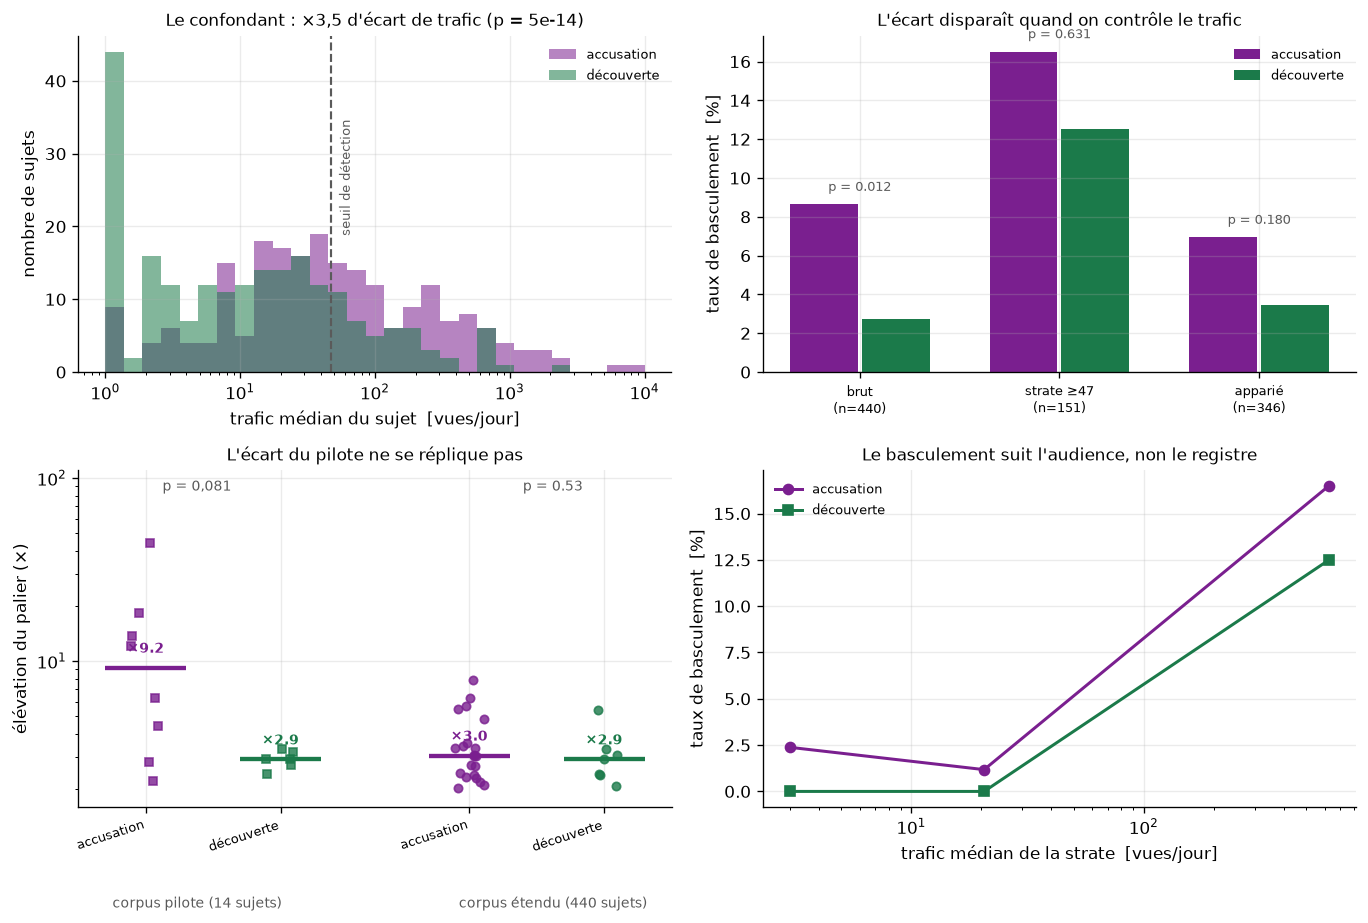

In [9]:
figure, axes = plt.subplots(2, 2, figsize=(11.5, 7.8))
audience, rates, persistence, strata = axes.ravel()

# (a) Le confondant : distributions de trafic.
bins = np.logspace(0, 4, 30)
for register, colour, name in [("accusation", PALETTE["field"], "accusation"),
                               ("discovery", PALETTE["remedy"], "découverte")]:
    audience.hist(traffic[register], bins=bins, alpha=0.55, color=colour, label=name)
audience.axvline(THRESHOLD, color=PALETTE["neutral"], linestyle="--", linewidth=1.3)
audience.text(THRESHOLD * 1.15, audience.get_ylim()[1] * 0.75, "seuil de détection",
              fontsize=7.5, color=PALETTE["neutral"], rotation=90, va="top")
audience.set_xscale("log")
audience.set_xlabel("trafic médian du sujet  [vues/jour]")
audience.set_ylabel("nombre de sujets")
audience.set_title(f"Le confondant : ×3,5 d'écart de trafic (p = {imbalance.pvalue:.0e})",
                   fontsize=10)
audience.legend(fontsize=8)

# (b) Taux de basculement, brut puis contrôlé.
labels = ["brut\n(n=440)", f"strate ≥{THRESHOLD:.0f}\n(n={na + nd})",
          f"apparié\n(n={2 * len(pairs)})"]
values_a = [pct_a, pa_, 100 * matched_a / len(pairs)]
values_d = [pct_d, pd_, 100 * matched_d / len(pairs)]
pvalues = [raw.pvalue, stratified.pvalue, mcnemar.pvalue if mcnemar else np.nan]
positions = np.arange(3)
rates.bar(positions - 0.18, values_a, 0.34, color=PALETTE["field"], label="accusation")
rates.bar(positions + 0.18, values_d, 0.34, color=PALETTE["remedy"], label="découverte")
for position, pvalue in zip(positions, pvalues):
    mark = f"p = {pvalue:.3f}" if pvalue >= 0.001 else f"p = {pvalue:.0e}"
    rates.text(position, max(values_a[position], values_d[position]) + 0.7, mark,
               ha="center", fontsize=7.5, color=PALETTE["neutral"])
rates.set_xticks(positions)
rates.set_xticklabels(labels, fontsize=8)
rates.set_ylabel("taux de basculement  [%]")
rates.set_title("L'écart disparaît quand on contrôle le trafic", fontsize=10)
rates.legend(fontsize=8)

# (c) La réplication de l'écart de persistance.
pilot = {"accusation": [44.2, 18.4, 13.7, 12.1, 6.3, 4.4, 2.8, 2.2],
         "discovery": [3.3, 3.2, 2.9, 2.9, 2.7, 2.4]}
rng = np.random.default_rng(0)
for offset, (corpus, source, marker) in enumerate(
    [("pilote", pilot, "s"), ("étendu", {k: list(v) for k, v in lifts.items()}, "o")]
):
    for shift_x, (register, colour) in enumerate(
        [("accusation", PALETTE["field"]), ("discovery", PALETTE["remedy"])]
    ):
        values = np.array(source[register], dtype=float)
        position = offset * 2.4 + shift_x
        jitter = position + rng.uniform(-0.11, 0.11, size=values.size)
        persistence.semilogy(jitter, values, marker, color=colour, markersize=5, alpha=0.8)
        median = float(np.median(values))
        persistence.hlines(median, position - 0.3, position + 0.3, color=colour, linewidth=2.6)
        persistence.annotate(f"×{median:.1f}", (position, median), textcoords="offset points",
                             xytext=(0, 9), ha="center", fontsize=8.5, color=colour,
                             fontweight="bold")

persistence.set_xticks([0, 1, 2.4, 3.4])
persistence.set_xticklabels(["accusation", "découverte", "accusation", "découverte"],
                            fontsize=7.5, rotation=18, ha="right")
persistence.text(0.20, -0.30, "corpus pilote (14 sujets)", transform=persistence.transAxes,
                 ha="center", fontsize=8.5, color=PALETTE["neutral"])
persistence.text(0.80, -0.30, "corpus étendu (440 sujets)", transform=persistence.transAxes,
                 ha="center", fontsize=8.5, color=PALETTE["neutral"])
persistence.set_ylim(1.6, 110.0)
persistence.text(0.20, 0.94, "p = 0,081", transform=persistence.transAxes, ha="center",
                 fontsize=8.5, color=PALETTE["neutral"])
persistence.text(0.80, 0.94, f"p = {replication.pvalue:.2f}", transform=persistence.transAxes,
                 ha="center", fontsize=8.5, color=PALETTE["neutral"])
persistence.set_ylabel("élévation du palier (×)")
persistence.set_title("L'écart du pilote ne se réplique pas", fontsize=10)

# (d) Taux de basculement par strate de trafic.
all_traffic = np.array([p["traffic"] for p in profiles])
edges = np.percentile(all_traffic, [0, 33, 66, 100])
centres, series_a, series_d = [], [], []
for low, high in zip(edges[:-1], edges[1:]):
    centres.append(np.sqrt(max(low, 1.0) * high))
    for group, target in ((accusation, series_a), (discovery, series_d)):
        inside = [p for p in group if low <= p["traffic"] <= high]
        target.append(100 * sum(p["shifted"] for p in inside) / max(len(inside), 1))

strata.semilogx(centres, series_a, "o-", color=PALETTE["field"], markersize=6,
                label="accusation")
strata.semilogx(centres, series_d, "s-", color=PALETTE["remedy"], markersize=6,
                label="découverte")
strata.set_xlabel("trafic médian de la strate  [vues/jour]")
strata.set_ylabel("taux de basculement  [%]")
strata.set_title("Le basculement suit l'audience, non le registre", fontsize=10)
strata.legend(fontsize=8)

save_figure(figure, "fig11_corpus_etendu.png")
plt.show()

## 7. Ce que le notebook établit

**L'écart de persistance du corpus pilote était un artefact de sélection.** ×9,2 contre ×2,9
sur quatorze sujets choisis à la main devient ×3,04 contre ×2,90 sur 440 sujets dérivés de
catégories ($p = 0{,}53$). Le protocole de sélection ne modifiait pas la précision du
résultat : il en modifiait le signe.

**L'écart de taux de basculement est un effet d'audience.** Le rapport de cotes brut de 3,4
($p = 0{,}014$) tombe à 1,38 dans une strate de trafic comparable ($p = 0{,}63$). Les sujets
d'accusation sont trois fois et demie plus consultés que ceux de découverte, et la détection
exige un seuil d'audience : le registre n'explique pas ce que l'audience explique déjà.

**Le nouveau protocole a son propre défaut.** L'appartenance à une catégorie est un
indicateur bruité du registre — « Lil Tay » est dans une catégorie de canulars, mais son
audience est celle d'une célébrité. Un bruit d'étiquetage attire tout écart vers zéro : le
résultat nul est donc compatible avec l'absence d'effet **comme** avec un effet dilué.

**Aucun des deux protocoles ne tranche.** Le pilote était biaisé par la sélection, l'étendu
est bruité par l'étiquetage. Ce n'est pas une impasse mais une spécification : un troisième
protocole devrait combiner un pool dérivé de catégories — pour l'absence de biais de
sélection — et une **validation du registre sujet par sujet**, indépendante de l'issue
mesurée. C'est un travail d'annotation, non de calcul.

**Et il faut le dire pour ce que c'est :** la seule différence entre registres émotionnels que
le projet avait mesurée ne survit pas à sa vérification. Le mécanisme de la charge émotionnelle
$\alpha$ reste, à ce stade, sans appui empirique — ni par le taux d'amplification
([notebook 09](09_calibration_visibilite.ipynb)), ni par la persistance.

## Pistes ouvertes

1. **Annoter le registre à la main sur le pool dérivé de catégories.** C'est le seul moyen
   de séparer l'absence d'effet de sa dilution. Deux cents sujets annotés en aveugle — sans
   voir leur série — suffiraient.
2. **Apparier sur le trafic dès la construction du corpus**, plutôt qu'en aval : tirer les
   sujets par paires de trafic comparable rendrait la comparaison immunisée au confondant
   principal.
3. **Abaisser le seuil de détection en agrégeant par semaine.** Le taux de basculement de
   2 à 8 % laisse plus de neuf sujets sur dix sans mesure ; une résolution hebdomadaire
   ferait passer le seuil d'audience et multiplierait les observations.
4. **Tester la spécificité du détecteur sur un registre témoin** — des sujets sans charge
   émotionnelle particulière et à trafic apparié — pour établir un taux de basculement de
   référence.